# Word Autoencoder for IMDB Sentiment

This notebook learns compact word embeddings by reconstructing review-level word-context profiles, then mean-pools those bottleneck vectors to train a classical sentiment classifier.

## What is an autoencoder?

An autoencoder is a neural network trained to reproduce its input. The encoder compresses an input vector into a lower-dimensional **bottleneck**, and the decoder expands that bottleneck into a reconstruction. A useful bottleneck must retain the regularities needed to rebuild the input instead of copying every coordinate directly.

Here, each word is represented by its positive pointwise mutual information with frequent context words that occur in the same training review. The autoencoder compresses that high-dimensional distributional profile. Words used in similar reviews should therefore receive similar bottleneck vectors. This is a deliberately simple distributional representation: review-level context captures broad topic and sentiment associations, but not local word order or distinct meanings of the same word.

## Experiment design

Reviews that become identical after the shared Phase 1 preprocessing and tokenization pipeline are deduplicated before a stratified 60/20/20 train/validation/test split. Vocabulary counts, context statistics, autoencoder fitting, feature scaling, and Logistic Regression fitting use training data only. The validation split checks the fixed design, while the test set is used once for the final report.

The word representation uses document-level co-occurrence rather than a sliding window. This keeps the experiment resource-conscious while satisfying the assigned freedom to choose any autoencoder input representation.

In [1]:
from collections import Counter
from pathlib import Path
import itertools
import json
import shutil
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch import nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.set_num_threads(min(8, max(1, torch.get_num_threads())))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu_name = None
if shutil.which("nvidia-smi"):
    result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=False,
    )
    if result.returncode == 0 and result.stdout.strip():
        gpu_name = result.stdout.strip().splitlines()[0]

cwd = Path.cwd().resolve()
repo_root = next(
    candidate
    for candidate in (cwd, *cwd.parents)
    if (candidate / "phase-1-machine-learning-nlp").exists()
)
part_02 = repo_root / "phase-1-machine-learning-nlp" / "02-preprocessing-tokenization"
sys.path.insert(0, str(part_02 / "src"))
from preprocessor import preprocess_text
from tokenizer import regex_tokenize

imdb_path = part_02 / "data" / "IMDB Dataset.csv"
if not imdb_path.exists():
    raise FileNotFoundError(
        "Download the IMDB 50K Reviews dataset and place 'IMDB Dataset.csv' in "
        f"{imdb_path.parent}. The CSV is intentionally ignored by Git."
    )

def model_tokens(text):
    cleaned = preprocess_text(str(text), remove_stopwords=False, apply_stemming=False)
    return [token for token in regex_tokenize(cleaned) if token.isalpha() and len(token) >= 2]

imdb = pd.read_csv(imdb_path).dropna(subset=["review", "sentiment"])
imdb["label"] = imdb["sentiment"].map({"negative": 0, "positive": 1})
if imdb["label"].isna().any():
    raise ValueError("Unexpected sentiment label found.")
imdb["tokens"] = imdb["review"].map(model_tokens)
imdb["model_visible_text"] = imdb["tokens"].str.join(" ")
if imdb["model_visible_text"].eq("").any():
    raise ValueError("Preprocessing produced an empty review.")
if imdb.groupby("model_visible_text")["label"].nunique().gt(1).any():
    raise ValueError("A model-visible review has conflicting labels.")

original_size = len(imdb)
imdb = imdb.drop_duplicates(subset="model_visible_text").reset_index(drop=True)
development, test = train_test_split(
    imdb,
    test_size=0.20,
    random_state=SEED,
    stratify=imdb["label"],
)
train, validation = train_test_split(
    development,
    test_size=0.25,
    random_state=SEED,
    stratify=development["label"],
)
split_frames = {"train": train, "validation": validation, "test": test}
for left, right in itertools.combinations(split_frames, 2):
    assert set(split_frames[left]["model_visible_text"]).isdisjoint(
        split_frames[right]["model_visible_text"]
    )

split_summary = pd.DataFrame(
    {
        name: {
            "reviews": len(frame),
            "positive proportion": frame["label"].mean(),
        }
        for name, frame in split_frames.items()
    }
).T

print(f"Operating-system GPU: {gpu_name or 'not detected'}")
print(f"PyTorch: {torch.__version__}; CUDA available: {torch.cuda.is_available()}")
print(f"Selected device: {device}; CPU threads: {torch.get_num_threads()}")
print(f"Reviews retained: {len(imdb):,} ({original_size - len(imdb):,} duplicates removed)")
print("Model-visible review overlap across splits: 0")
display(split_summary.style.format({"positive proportion": "{:.4f}"}))

Operating-system GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
PyTorch: 2.13.0+cpu; CUDA available: False
Selected device: cpu; CPU threads: 6
Reviews retained: 49,580 (420 duplicates removed)
Model-visible review overlap across splits: 0


,reviews,positive proportion
train,29748.000000,0.5019
validation,9916.000000,0.5019
test,9916.000000,0.5019


## Training-only word-context profiles

The 8,000 most frequent training words become embedding targets, while the 2,000 most frequent form the context dimensions. For each training review, binary presence records which targets and contexts co-occur. Multiplying the two sparse document-word matrices counts review-level co-occurrence.

Positive PMI removes associations no stronger than chance and emphasizes informative relationships. A word's self-context is removed, each row is L2-normalized, and no validation or test review contributes to these profiles.

In [2]:
TARGET_VOCABULARY_SIZE = 8_000
CONTEXT_VOCABULARY_SIZE = 2_000
HIDDEN_DIMENSION = 256
EMBEDDING_DIMENSION = 64

training_counts = Counter(token for tokens in train["tokens"] for token in tokens)
target_words = [word for word, _ in training_counts.most_common(TARGET_VOCABULARY_SIZE)]
context_words = target_words[:CONTEXT_VOCABULARY_SIZE]
target_vocabulary = {word: index for index, word in enumerate(target_words)}
context_vocabulary = {word: index for index, word in enumerate(context_words)}

def binary_document_word_matrix(token_rows, vocabulary):
    rows = []
    columns = []
    for row_index, tokens in enumerate(token_rows):
        document_columns = {vocabulary[token] for token in tokens if token in vocabulary}
        columns.extend(document_columns)
        rows.extend([row_index] * len(document_columns))
    values = np.ones(len(rows), dtype=np.float32)
    return csr_matrix(
        (values, (rows, columns)),
        shape=(len(token_rows), len(vocabulary)),
        dtype=np.float32,
    )

context_start = time.perf_counter()
train_target_presence = binary_document_word_matrix(train["tokens"].tolist(), target_vocabulary)
train_context_presence = binary_document_word_matrix(train["tokens"].tolist(), context_vocabulary)
cooccurrence = (train_target_presence.T @ train_context_presence).toarray().astype(np.float32)
for context_index, word in enumerate(context_words):
    cooccurrence[target_vocabulary[word], context_index] = 0.0

total = float(cooccurrence.sum())
row_totals = cooccurrence.sum(axis=1, keepdims=True)
column_totals = cooccurrence.sum(axis=0, keepdims=True)
denominator = row_totals @ column_totals
with np.errstate(divide="ignore", invalid="ignore"):
    ppmi = np.maximum(np.log((cooccurrence * total) / denominator), 0.0)
ppmi[~np.isfinite(ppmi)] = 0.0
row_norms = np.linalg.norm(ppmi, axis=1, keepdims=True)
word_profiles = (ppmi / np.maximum(row_norms, 1e-12)).astype(np.float32)
profile_seconds = time.perf_counter() - context_start

assert word_profiles.shape == (TARGET_VOCABULARY_SIZE, CONTEXT_VOCABULARY_SIZE)
assert np.isfinite(word_profiles).all()
assert np.allclose(np.linalg.norm(word_profiles, axis=1), 1.0, atol=1e-5)

profile_summary = pd.DataFrame(
    {
        "value": [
            TARGET_VOCABULARY_SIZE,
            CONTEXT_VOCABULARY_SIZE,
            int(np.count_nonzero(word_profiles)),
            np.count_nonzero(word_profiles) / word_profiles.size,
            profile_seconds,
        ]
    },
    index=["target words", "context dimensions", "positive PPMI values", "matrix density", "build seconds"],
)
display(profile_summary.style.format({"value": "{:.4f}"}))

,value
target words,8000.0000
context dimensions,2000.0000
positive PPMI values,7455872.0000
matrix density,0.4660
build seconds,4.0301


## Autoencoder and bottleneck

The encoder reduces 2,000 context features through a 256-unit ReLU layer to a 64-dimensional linear bottleneck. The decoder mirrors that structure and reconstructs the normalized PPMI profile. Mean squared error measures reconstruction quality.

The fixed twelve-epoch run reserves a reproducible random 10% of word rows for reconstruction validation. This validation monitors whether the mapping generalizes to word profiles not used for parameter updates; it is not used to choose an epoch or tune the architecture.

In [3]:
class WordAutoencoder(nn.Module):
    def __init__(self, input_dimension, hidden_dimension, embedding_dimension):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dimension, hidden_dimension),
            nn.ReLU(),
            nn.Linear(hidden_dimension, embedding_dimension),
        )
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dimension, hidden_dimension),
            nn.ReLU(),
            nn.Linear(hidden_dimension, input_dimension),
        )

    def forward(self, inputs):
        embedding = self.encoder(inputs)
        return self.decoder(embedding)

model = WordAutoencoder(
    CONTEXT_VOCABULARY_SIZE,
    HIDDEN_DIMENSION,
    EMBEDDING_DIMENSION,
).to(device)
for module in model.modules():
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)

word_train_indices, word_validation_indices = train_test_split(
    np.arange(TARGET_VOCABULARY_SIZE),
    test_size=0.10,
    random_state=SEED,
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
BATCH_SIZE = 128
EPOCHS = 12

def reconstruction_loss(indices):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for start in range(0, len(indices), BATCH_SIZE):
            batch_indices = indices[start : start + BATCH_SIZE]
            inputs = torch.from_numpy(word_profiles[batch_indices]).to(device)
            total_loss += criterion(model(inputs), inputs).item() * len(batch_indices)
    return total_loss / len(indices)

history = []
training_start = time.perf_counter()
for epoch in range(1, EPOCHS + 1):
    model.train()
    shuffled = np.random.default_rng(SEED + epoch).permutation(word_train_indices)
    total_train_loss = 0.0
    for start in range(0, len(shuffled), BATCH_SIZE):
        batch_indices = shuffled[start : start + BATCH_SIZE]
        inputs = torch.from_numpy(word_profiles[batch_indices]).to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(inputs), inputs)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * len(batch_indices)
    epoch_train_loss = total_train_loss / len(shuffled)
    epoch_validation_loss = reconstruction_loss(word_validation_indices)
    history.append(
        {"epoch": epoch, "train loss": epoch_train_loss, "validation loss": epoch_validation_loss}
    )
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | train loss {epoch_train_loss:.6f} | "
        f"validation loss {epoch_validation_loss:.6f}"
    )
training_seconds = time.perf_counter() - training_start

parameter_count = sum(parameter.numel() for parameter in model.parameters())
history_frame = pd.DataFrame(history)
print(f"Trainable parameters: {parameter_count:,}")
print(f"Autoencoder training and validation seconds: {training_seconds:.2f}")

Epoch 01/12 | train loss 0.000351 | validation loss 0.000332


Epoch 02/12 | train loss 0.000325 | validation loss 0.000316


Epoch 03/12 | train loss 0.000311 | validation loss 0.000307


Epoch 04/12 | train loss 0.000304 | validation loss 0.000302


Epoch 05/12 | train loss 0.000300 | validation loss 0.000298


...

Epoch 08/12 | train loss 0.000290 | validation loss 0.000290


Epoch 09/12 | train loss 0.000288 | validation loss 0.000288


Epoch 10/12 | train loss 0.000286 | validation loss 0.000287


Epoch 11/12 | train loss 0.000285 | validation loss 0.000286


Epoch 12/12 | train loss 0.000283 | validation loss 0.000284
Trainable parameters: 1,059,344
Autoencoder training and validation seconds: 5.90


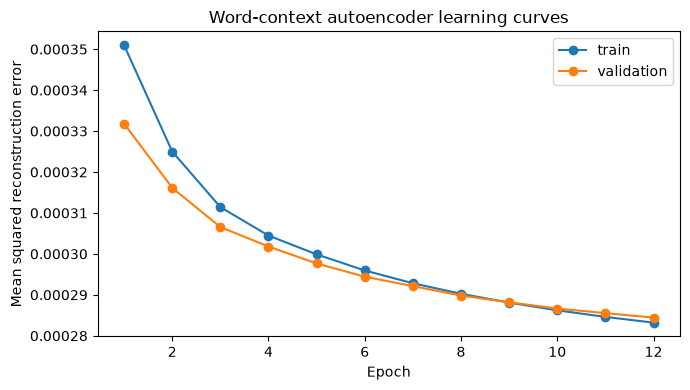

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_frame["epoch"], history_frame["train loss"], marker="o", label="train")
ax.plot(history_frame["epoch"], history_frame["validation loss"], marker="o", label="validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean squared reconstruction error")
ax.set_title("Word-context autoencoder learning curves")
ax.legend()
fig.tight_layout()
plt.show()

## Inspecting the learned word space

Cosine similarity in the bottleneck provides a small qualitative check. These neighbors are not an external semantic benchmark: they only show which frequent words received similar review-level context profiles after compression.

In [5]:
model.eval()
with torch.no_grad():
    word_embeddings = model.encoder(torch.from_numpy(word_profiles).to(device)).cpu().numpy()
embedding_norms = np.linalg.norm(word_embeddings, axis=1, keepdims=True)
normalized_embeddings = word_embeddings / np.maximum(embedding_norms, 1e-12)

def nearest_words(query, count=5):
    query_index = target_vocabulary[query]
    similarities = normalized_embeddings @ normalized_embeddings[query_index]
    neighbors = np.argsort(similarities)[::-1]
    neighbors = [index for index in neighbors if index != query_index][:count]
    return [(target_words[index], similarities[index]) for index in neighbors]

queries = [word for word in ["excellent", "awful", "funny", "boring", "actor"] if word in target_vocabulary]
neighbor_rows = []
for query in queries:
    for rank, (neighbor, similarity) in enumerate(nearest_words(query), start=1):
        neighbor_rows.append(
            {"query": query, "rank": rank, "neighbor": neighbor, "cosine similarity": similarity}
        )
display(pd.DataFrame(neighbor_rows).style.format({"cosine similarity": "{:.4f}"}))

,query,rank,neighbor,cosine similarity
0,excellent,1,superb,0.9557
1,excellent,2,outstanding,0.9292
2,excellent,3,performances,0.9253
3,excellent,4,terrific,0.9007
4,excellent,5,exceptional,0.8992
5,awful,1,terrible,0.9870
6,awful,2,worse,0.9867
7,awful,3,worst,0.9821
8,awful,4,avoid,0.9583
9,awful,5,horrible,0.9577


## Sentiment classification from bottleneck embeddings

Each review becomes the mean of its in-vocabulary word embeddings. This removes word order and ignores words outside the training vocabulary, so token coverage is reported. A StandardScaler fitted on training features is followed by a fixed Logistic Regression classifier. Validation and test use only transformations learned from training data.

,accuracy,precision,recall,F1,ROC AUC
split,,,,,
validation,0.8635,0.8582,0.8720,0.8651,0.9346
test,0.8639,0.8579,0.8734,0.8656,0.9344


,train,validation,test
token coverage,91.5750%,91.3923%,91.4479%


              precision    recall  f1-score   support

    negative     0.8701    0.8542    0.8621      4939
    positive     0.8579    0.8734    0.8656      4977

    accuracy                         0.8639      9916
   macro avg     0.8640    0.8638    0.8638      9916
weighted avg     0.8640    0.8639    0.8638      9916



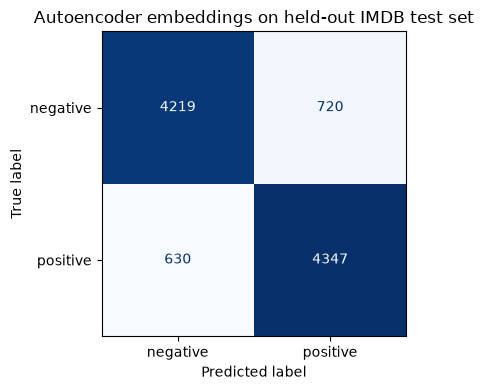

RESULT_SUMMARY={"context_dimensions": 2000, "duplicates_removed": 420, "embedding_dimensions": 64, "feature_and_classifier_seconds": 4.562956199981272, "final_train_loss": 0.0002832066864033954, "final_validation_loss": 0.00028443851042538883, "parameters": 1059344, "profile_seconds": 4.030089500010945, "target_words": 8000, "test_accuracy": 0.86385639370714, "test_coverage": 0.9144794183880356, "test_f1": 0.8655913978494624, "test_precision": 0.8579040852575488, "test_recall": 0.8734177215189873, "test_reviews": 9916, "test_roc_auc": 0.9344084835190245, "train_reviews": 29748, "training_seconds": 5.903252399992198, "validation_reviews": 9916}


In [6]:
def review_embedding_features(token_rows):
    rows = []
    columns = []
    values = []
    retained_tokens = 0
    total_tokens = 0
    for row_index, tokens in enumerate(token_rows):
        counts = Counter(token for token in tokens if token in target_vocabulary)
        total_tokens += len(tokens)
        retained_tokens += sum(counts.values())
        denominator = max(1, sum(counts.values()))
        for token, count in counts.items():
            rows.append(row_index)
            columns.append(target_vocabulary[token])
            values.append(count / denominator)
    weights = csr_matrix(
        (np.asarray(values, dtype=np.float32), (rows, columns)),
        shape=(len(token_rows), TARGET_VOCABULARY_SIZE),
        dtype=np.float32,
    )
    return np.asarray(weights @ word_embeddings, dtype=np.float32), retained_tokens / total_tokens

feature_start = time.perf_counter()
features = {}
coverage = {}
for name, frame in split_frames.items():
    features[name], coverage[name] = review_embedding_features(frame["tokens"].tolist())

scaler = StandardScaler()
X_train = scaler.fit_transform(features["train"])
X_validation = scaler.transform(features["validation"])
X_test = scaler.transform(features["test"])
y_train = train["label"].to_numpy()
y_validation = validation["label"].to_numpy()
y_test = test["label"].to_numpy()

classifier = LogisticRegression(C=1.0, max_iter=1_000, random_state=SEED)
classifier.fit(X_train, y_train)

def classification_metrics(name, labels, matrix):
    probabilities = classifier.predict_proba(matrix)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    return {
        "split": name,
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions),
        "recall": recall_score(labels, predictions),
        "F1": f1_score(labels, predictions),
        "ROC AUC": roc_auc_score(labels, probabilities),
    }, probabilities, predictions

validation_metrics, validation_probabilities, validation_predictions = classification_metrics(
    "validation", y_validation, X_validation
)
test_metrics, test_probabilities, test_predictions = classification_metrics("test", y_test, X_test)
metrics_frame = pd.DataFrame([validation_metrics, test_metrics]).set_index("split")
feature_seconds = time.perf_counter() - feature_start

display(metrics_frame.style.format("{:.4f}"))
display(pd.DataFrame({"token coverage": coverage}).T.style.format("{:.4%}"))
print(classification_report(y_test, test_predictions, target_names=["negative", "positive"], digits=4))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, test_predictions),
    display_labels=["negative", "positive"],
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Autoencoder embeddings on held-out IMDB test set")
fig.tight_layout()
plt.show()

summary = {
    "duplicates_removed": original_size - len(imdb),
    "train_reviews": len(train),
    "validation_reviews": len(validation),
    "test_reviews": len(test),
    "target_words": TARGET_VOCABULARY_SIZE,
    "context_dimensions": CONTEXT_VOCABULARY_SIZE,
    "embedding_dimensions": EMBEDDING_DIMENSION,
    "parameters": parameter_count,
    "profile_seconds": profile_seconds,
    "training_seconds": training_seconds,
    "feature_and_classifier_seconds": feature_seconds,
    "final_train_loss": history_frame.iloc[-1]["train loss"],
    "final_validation_loss": history_frame.iloc[-1]["validation loss"],
    "test_coverage": coverage["test"],
    **{f"test_{key.lower().replace(' ', '_')}": value for key, value in test_metrics.items() if key != "split"},
}
print("RESULT_SUMMARY=" + json.dumps(summary, sort_keys=True))

## Observations

The autoencoder reduced 2,000 training-only context dimensions to 64 values per word. Reconstruction loss fell from the first epoch and finished at `0.000283` on training word profiles and `0.000284` on held-out word profiles. The small remaining gap suggests the fixed model learned regularities that transfer across vocabulary rows rather than only memorizing the update set.

Mean-pooled bottleneck embeddings retained `91.45%` of test tokens. The fixed Logistic Regression classifier reached test accuracy `0.8639`, precision `0.8579`, recall `0.8734`, F1 `0.8656`, and ROC AUC `0.9344`. This is a useful but weaker sentiment representation than the earlier sparse TF-IDF models: averaging word vectors discards order, negation structure, and rare words, while the review-level context objective mixes topic and sentiment.

The NVIDIA GPU was detected by the operating system, but the installed PyTorch build exposes CPU execution only. Building the PPMI profiles took `4.03` seconds, and twelve autoencoder epochs with validation took `5.90` seconds. No learned model or downloaded dataset is saved in the repository; the executed notebook retains the compact results.